# Generate coefficients for the trajectories
This script takes some points as inputs (maxima and minima of the desired trajectory).
It fits cubic splines to the points with the desired properties and outputs the
coefficients of the cubic splines. With these coefficients, the trajectories can
be rendered in Unity.

## Difficult trajectory

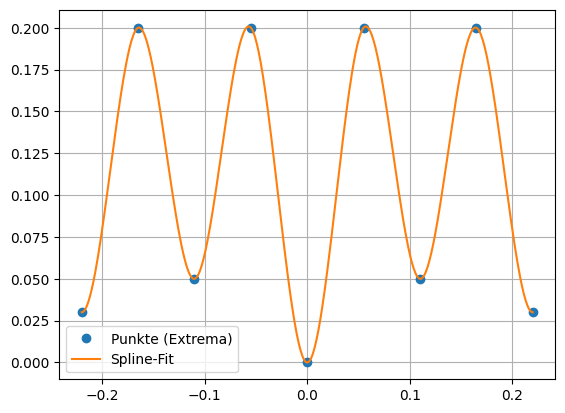



Difficult trajectory
Segment 0: if x in [-0.22, -0.165]: y = -1963.078244*(x - -0.220000)**3 + 164.167651*(x - -0.220000)**2 + 0.000000*(x - -0.220000) + 0.030000
Segment 1: if x in [-0.165, -0.11]: y = 1922.292583*(x - -0.165000)**3 + -159.740260*(x - -0.165000)**2 + 0.243506*(x - -0.165000) + 0.200000
Segment 2: if x in [-0.11, -0.055]: y = -1999.570677*(x - -0.110000)**3 + 157.438017*(x - -0.110000)**2 + 0.116883*(x - -0.110000) + 0.050000
Segment 3: if x in [-0.055, 0.0]: y = 2169.153161*(x - -0.055000)**3 + -172.491145*(x - -0.055000)**2 + -0.711039*(x - -0.055000) + 0.200000
Segment 4: if x in [0.0, 0.055]: y = -2169.153161*(x - 0.000000)**3 + 185.419126*(x - 0.000000)**2 + 0.000000*(x - 0.000000) + 0.000000
Segment 5: if x in [0.055, 0.11]: y = 1999.570677*(x - 0.055000)**3 + -172.491145*(x - 0.055000)**2 + 0.711039*(x - 0.055000) + 0.200000
Segment 6: if x in [0.11, 0.165]: y = -1922.292583*(x - 0.110000)**3 + 157.438017*(x - 0.110000)**2 + -0.116883*(x - 0.110000) + 0.050000

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline

points = [
    (-0.22, 0.03),
    (-0.165, 0.20),
    (-0.11, 0.05),
    (-0.055, 0.20),
    (0.0, 0.00),
    (0.055, 0.20),
    (0.11, 0.05),
    (0.165, 0.20),
    (0.22, 0.03),
]

x, y = zip(*points)

# Ableitungen an den Rändern = 0 (Minima/Maxima)
cs = CubicSpline(x, y, bc_type=((1, 0.0), (1, 0.0)))

x_fit = np.linspace(min(x), max(x), 500)
y_fit = cs(x_fit)

plt.plot(x, y, 'o', label='Punkte (Extrema)')
plt.plot(x_fit, y_fit, '-', label='Spline-Fit')
plt.legend()
plt.grid()
plt.show()

# # Exportieren
print("\n\nDifficult trajectory")
for i in range(len(cs.x) - 1):
    x0 = cs.x[i]
    coeffs = cs.c[:, i]  # [a, b, c, d] für Segment i
    print(f"Segment {i}: if x in [{x0}, {cs.x[i+1]}]: y = "
          f"{coeffs[0]:.6f}*(x - {x0:.6f})**3 + "
          f"{coeffs[1]:.6f}*(x - {x0:.6f})**2 + "
          f"{coeffs[2]:.6f}*(x - {x0:.6f}) + "
          f"{coeffs[3]:.6f}")


## Easy trajectory

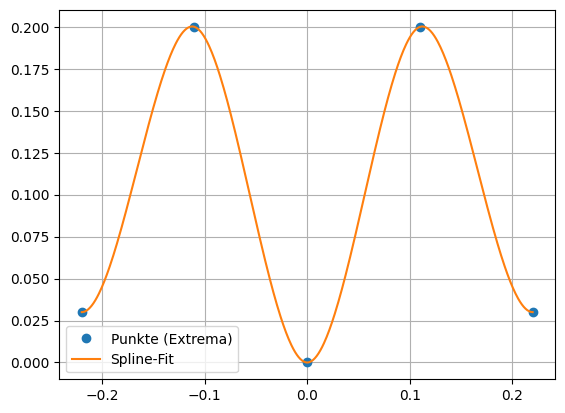

Segment 0: if x in [-0.22, -0.11]: y = -272.351615*(x - -0.220000)**3 + 44.008264*(x - -0.220000)**2 + 0.000000*(x - -0.220000) + 0.030000
Segment 1: if x in [-0.11, 0.0]: y = 283.621337*(x - -0.110000)**3 + -45.867769*(x - -0.110000)**2 + -0.204545*(x - -0.110000) + 0.200000
Segment 2: if x in [0.0, 0.11]: y = -283.621337*(x - 0.000000)**3 + 47.727273*(x - 0.000000)**2 + 0.000000*(x - 0.000000) + 0.000000
Segment 3: if x in [0.11, 0.22]: y = 272.351615*(x - 0.110000)**3 + -45.867769*(x - 0.110000)**2 + 0.204545*(x - 0.110000) + 0.200000


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline

points = [
    (-0.22, 0.03),
    (-0.11, 0.20),
    (0.0, 0.00),
    (0.11, 0.2),
    (0.22, 0.03),
]

x, y = zip(*points)

# Ableitungen an den Rändern = 0 (Minima/Maxima)
cs = CubicSpline(x, y, bc_type=((1, 0.0), (1, 0.0)))

x_fit = np.linspace(min(x), max(x), 500)
y_fit = cs(x_fit)

plt.plot(x, y, 'o', label='Punkte (Extrema)')
plt.plot(x_fit, y_fit, '-', label='Spline-Fit')
plt.legend()
plt.grid()
plt.show()

# # Exportieren
for i in range(len(cs.x) - 1):
    x0 = cs.x[i]
    coeffs = cs.c[:, i]  # [a, b, c, d] für Segment i
    print(f"Segment {i}: if x in [{x0}, {cs.x[i+1]}]: y = "
          f"{coeffs[0]:.6f}*(x - {x0:.6f})**3 + "
          f"{coeffs[1]:.6f}*(x - {x0:.6f})**2 + "
          f"{coeffs[2]:.6f}*(x - {x0:.6f}) + "
          f"{coeffs[3]:.6f}")
